In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.min_features import min_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

# pos = pd.read_csv('data/raw/player_positions/player_positions.csv')
s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
210,2025-26,1629599,Amir Coffey,Amir,1610612756,PHX,Phoenix Suns,22501185,2026-04-10T00:00:00,PHX @ LAL,L,20.550000,3,6,0.500,1,2,0.500,0,0,0.000,0,2,2,0,1,1,0,0,2,0,7,-11,11.4,0,0,12.0,1,20:33,1,82.4,82.9,82.9,114.2,115.4,115.4,-31.8,-32.5,-32.5,0.000,0.0,0.0,0.000,0.118,0.051,14.3,14.3,0.583,0.583,0.146,0.155,94.22,93.43,77.86,93.43,0.056,41,3.0,6.0,26,77,0.338,7,40,0.175,14,21,0.667,18,29,47,17,23.0,8,1,3,18,18,73,-28.0,80.0,81.1,113.2,112.2,-33.2,-31.1,0.654,0.74,13.2,0.400,0.816,0.570,0.256,0.383,0.423,90.2,90.0,75.00,90,0.255,1610612747,LAL,Los Angeles Lakers,35,69,0.507,8,20,0.400,23,30,0.767,4,31,35,27,11.0,17,3,1,18,18,101,28.0,113.2,112.2,80.0,81.1,33.2,31.1,0.771,2.45,21.8,0.184,0.600,0.430,0.122,0.565,0.614,90.2,90.0,75.00,90,0.745,NaN,SG,28.0,0
211,2025-26,1627739,Kris Dunn,Kris,1610612746,LAC,LA Clippers,22501183,2026-04-10T00:00:00,LAC @ POR,L,26.566667,2,3,0.667,1,2,0.500,0,0,0.000,1,4,5,1,2,0,0,0,4,1,5,3,10.5,0,0,12.0,1,26:34,1,128.6,131.4,131.4,117.5,123.1,123.1,11.2,8.3,8.3,0.043,0.5,16.7,0.042,0.143,0.096,33.3,33.3,0.833,0.833,0.088,0.086,96.26,93.05,77.54,93.05,0.031,51,2.0,3.0,36,83,0.434,13,40,0.325,12,12,1.000,10,25,35,17,17.0,6,3,7,27,15,97,-19.0,101.8,102.1,116.7,122.1,-14.9,-20.0,0.472,1.00,13.8,0.250,0.574,0.411,0.179,0.512,0.549,97.3,95.0,79.17,95,0.350,1610612757,POR,Portland Trail Blazers,37,83,0.446,12,39,0.308,30,35,0.857,14,32,46,23,15.0,12,7,3,15,27,116,19.0,116.7,122.1,101.8,102.1,14.9,20.0,0.622,1.53,16.8,0.426,0.750,0.589,0.158,0.518,0.589,97.3,95.0,79.17,95,0.650,G,PG,31.0,1
212,2025-26,1641771,Jalen Slawson,Jalen,1610612754,IND,Indiana Pacers,22501175,2026-04-10T00:00:00,IND vs. PHI,L,15.183333,0,4,0.000,0,2,0.000,2,2,1.000,2,3,5,3,5,0,1,0,2,3,2,-14,10.5,0,0,12.0,1,15:11,1,59.0,59.4,59.4,101.9,100.0,100.0,-42.8,-40.6,-40.6,0.500,0.6,23.1,0.111,0.125,0.119,38.5,38.8,0.000,0.205,0.270,0.273,102.11,102.74,85.62,102.74,-0.041,32,0.0,4.0,33,88,0.375,14,50,0.280,14,16,0.875,10,42,52,25,21.0,6,8,2,15,14,94,-11.0,88.6,89.5,100.6,101.0,-12.0,-11.4,0.758,1.19,17.5,0.228,0.723,0.492,0.200,0.455,0.495,105.2,104.5,87.08,105,0.456,1610612755,PHI,Philadelphia 76ers,42,104,0.404,5,29,0.172,16,19,0.842,16,42,58,17,8.0,13,2,8,14,15,105,11.0,100.6,101.0,88.6,89.5,12.0,11.4,0.405,2.13,12.2,0.277,0.772,0.508,0.077,0.428,0.467,105.2,104.5,87.08,104,0.544,NaN,SF,26.0,0
205,2025-26,1642362,Payton Sandfort,Payton,1610612760,OKC,

In [3]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(3)
    df = min_features(df)
    df['TEAM_MIN_RANK_BY_POS_L10'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['MIN_roll10']
    .rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_BY_POS_L10'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['USG_PCT_roll10']
    .rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_BY_POS_L10'] = (df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_BY_POS_L10'] = (df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['USG_EWM_L10'] = (df.groupby('PLAYER_ID')['USG_PCT'].transform(lambda x: x.shift(1).ewm(span=12, adjust=False).mean()))
    df['USG_EWM_L5'] = (df.groupby('PLAYER_ID')['USG_PCT'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_EWM_L10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=12, adjust=False).mean()))
    df['MIN_EWM_L5'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_EWM_L3'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean()))
    df['MIN_TREND'] = (df['MIN_EWM_L3'] - df['MIN_EWM_L10'])
    df['STARTER_X_MIN_AVG'] = df['STARTING'] * df['MIN_season_avg']
    df['AGE_X_B2B'] = df['age'] * df['IS_B2B']
    df['HOME_X_MIN_AVG'] = df['IS_HOME'] * df['MIN_season_avg']
    df['EXPECTED_MARGIN'] = (df['TEAM_NET_RATING_roll5'] - df['OPP_NET_RATING_roll5']).abs()
    min_max_l10 = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).max())
    min_min_l10 = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).min())
    df['ROTATION_GAP_L10'] = min_max_l10 - min_min_l10

    # Calculate the player's personal season-to-date baseline
    player_stats = df.groupby('PLAYER_ID')['MIN']
    # Use expanding() to avoid look-ahead bias (only uses games played UP TO that date)
    df['SEASON_MEAN'] = player_stats.transform(lambda x: x.expanding().mean().shift(1))
    df['SEASON_STD'] = player_stats.transform(lambda x: x.expanding().std().shift(1))
    # The Z-score of their current 10-game average relative to their own season
    df['MIN_ROLE_Z_SCORE'] = (df['MIN_roll10'] - df['SEASON_MEAN']) / df['SEASON_STD']
    df['MIN_VOLATILITY_L10'] = df.groupby('PLAYER_ID')['MIN'].transform(
    lambda x: x.rolling(window=10, min_periods=1).std().shift(1))
    df['MIN_VOLATILITY_RELATIVE'] = df['MIN_VOLATILITY_L10'] / df['MIN_roll10']

    df['HIGH_MIN_PLAYER'] = (df['MIN_roll10'] > 30).astype(int)
    df['HIGH_MIN_TIER'] = np.nan
    mask = df['MIN_EWM_L10'].notna()
    df.loc[mask, 'HIGH_MIN_TIER'] = pd.cut(
        df.loc[mask, 'MIN_EWM_L10'],
        bins=[0, 20, 25, 30, 34, 100],
        labels=[0, 1, 2, 3, 4],
        include_lowest=True,).astype(int)
        
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    le = LabelEncoder()
    df['POSITION_ENC'] = le.fit_transform(df['pos'])
    df['PLAYER_ENC'] = le.fit_transform(df['PLAYER_NAME'])
    df['ROLE_LOCK'] = (
    df['STARTER_ROLL10_PCT'] * df['MIN_std10'].apply(lambda x: 1/x))  # high start% + low variance = locked in role = safest bet
    df['ROLE_SHOCK'] = (
    df['MIN_EWM_L5'] - df['MIN_EWM_L10']          # short vs long term gap
    ) / df['MIN_EWM_L10']                            # normalized as % change
    df['PM_PER_MIN']    = df['PLUS_MINUS_lag1'] / df['MIN_lag1'].replace(0, np.nan)
    df['PM_PER_MIN_R10']= df['PM_PER_MIN'].transform(lambda x: x.shift(1).rolling(10).mean())
    # df["MIN_ABOVE_35_L10"] = (
    # (df["MIN"] >= 35)
    # .groupby(df["PLAYER_ID"])
    # .shift(1)                       # exclude current game to avoid leakage
    # .rolling(10, min_periods=1)
    # .sum()
    # .reset_index(level=0, drop=True))
    
    player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    lambda x: (x >= 15).mean())
    eligible = player_avgs[player_avgs >= 0.50].index
    df = df[df['PLAYER_ID'].isin(eligible)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df[df['PLAYER_NAME'] == 'LeBron James']
df.to_csv('data/processed/training/S26_TRAINING_MIN.csv', index=False)

(81179, 317)


In [6]:
MIN_FEATURES = [
    # --- Tier 1: Core Role (Anchor & Recent Baseline) ---
    'STARTING',         # Heavy signal for rotation status
    'MIN_season_avg', # new
    'MIN_EWM_L10',               # Long-term stable baseline
    'MIN_TREND',                 # (MIN_EWM_L3 - MIN_EWM_L12) - Role direction
    'STARTER_ROLL10_PCT',
    'MIN_ROLE_Z_SCORE',          # Role change relative to season avg
    'ROLE_LOCK',                 # Binary flag for "untouchable" starters

    # --- Tier 2: Team Context (Depth Chart Hierarchy) ---
    'TEAM_MIN_RANK_L10',          # Rank in team's minutes hierarchy
    'TEAM_USG_RANK_L10',          # Distinguishes high-usage vs. low-usage roles
    'MIN_share_proxy',           # Player's % of team's available minutes

    # --- Tier 3: Situational & Variance (The Tail Shifters) ---
    'DAYS_REST',                 # Fatigue and rest-capping signal
    'ROTATION_GAP_L10',           # Identifies high-variance "fringe" players
    'POSITION_ENC',               # Positional constraints (e.g., Big vs. Small)
    'PACE_DIFFERENTIAL',
    'GP',
    'IS_TOP_STAR', # new addition
    'ACTIVE_STARS_COUNT',  # new addition'
]

In [7]:
from sklearn.preprocessing import StandardScaler

# Define which features to scale (Continuous) vs ignore (Binary/Ordinal)
binary_cols = ['STARTING', 'IS_TOP_STAR', 'ACTIVE_STARS_COUNT', 'POSITION_ENC', 
'TEAM_MIN_RANK_L10', 'TEAM_USG_RANK_L10', 'DAYS_REST', 'GP']
continuous_cols = [c for c in MIN_FEATURES if c not in binary_cols]

ppm_df = df[MIN_FEATURES + ["MIN", "GAME_DATE"]].dropna()

# 2. Split Data
split_date = ppm_df["GAME_DATE"].quantile(0.75)
train_mask = ppm_df["GAME_DATE"] <= split_date
val_mask = ~train_mask

X_train = ppm_df.loc[train_mask, MIN_FEATURES].copy()
X_val = ppm_df.loc[val_mask, MIN_FEATURES].copy()
y_train = ppm_df.loc[train_mask, "MIN"]
y_val = ppm_df.loc[val_mask, "MIN"]

# 3. Apply Scaling (Only to continuous features)
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])

# 4. Training Loop
quantiles = [0.10, 0.50, 0.90]
quantile_models = {}
quantile_preds = {}

for q in quantiles:
    print(f"Training Quantile: {q}...")
    xgb_q = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q,
        n_estimators=1085,
        max_depth=3,
        learning_rate=0.016830306319220507,
        subsample=0.560576121654833,
        colsample_bytree=0.7918682725578758,
        reg_alpha=0.2923179330388192,
        reg_lambda=0.16891787981446876,
        min_child_weight=2,
        n_jobs=-1,
        random_state=42
    )
    xgb_q.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    quantile_models[f"q_{q:.2f}"] = xgb_q
    quantile_preds[f"q_{q:.2f}"] = xgb_q.predict(X_val)

# 5. Diagnostic Output
results = X_val.copy()
results["Actual"] = y_val.values
results["Lower_10"] = quantile_preds["q_0.10"]
results["Median_50"] = quantile_preds["q_0.50"]
results["Upper_90"] = quantile_preds["q_0.90"]

mae = mean_absolute_error(y_val, results["Median_50"])
print(f"\nMedian Model MAE: {mae:.3f} PTS/min")
print(f"Median Model R2: {r2_score(y_val, results['Median_50']):.3f}")


Training Quantile: 0.1...
Training Quantile: 0.5...
Training Quantile: 0.9...

Median Model MAE: 4.308 PTS/min
Median Model R2: 0.549


In [ ]:
# import optuna

# def objective(trial):
#     # 1. Define the search space
#     params = {
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
#         "n_estimators": trial.suggest_int("n_estimators", 500, 1500),
#         "subsample": trial.suggest_float("subsample", 0.5, 0.9),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),
#         "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 1.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 1.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#     }
    
#     # 2. Train model with trial parameters
#     model = XGBRegressor(
#         objective="reg:quantileerror",
#         quantile_alpha=0.50, # Tune the Median model
#         **params,
#         n_jobs=-1,
#         random_state=42
#     )
    
#     model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
#     # 3. Use MAE as the metric to minimize
#     preds = model.predict(X_val)
#     return mean_absolute_error(y_val, preds)

# # 4. Execute the study
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=50)

# print("Best Parameters:", study.best_params)

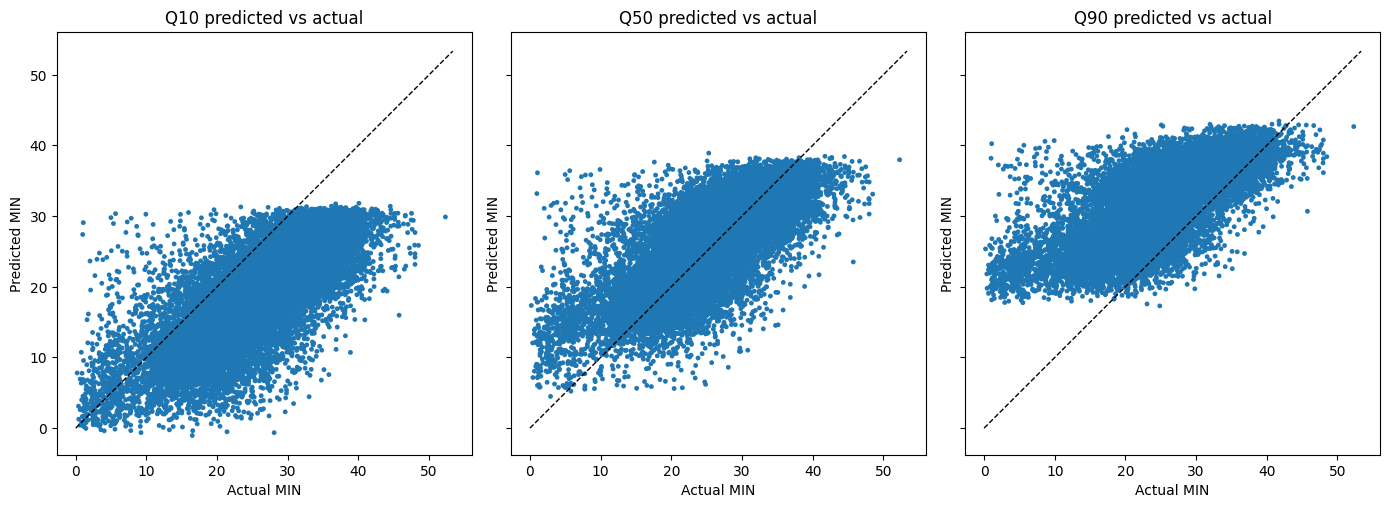

Q10 coverage: 0.1089398828731923
Q50 coverage: 0.5257559459782479
Q90 coverage: 0.9049241066092985
Coverage (10–90 interval): 79.60%


In [8]:
import matplotlib.pyplot as plt

y_true = y_val
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual MIN")
    ax.set_ylabel("Predicted MIN")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "coverage:", (y_true <= y_pred).mean())

# assumes you trained these quantiles and stored predictions
pred_low  = quantile_preds["q_0.10"]
pred_mid  = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_val >= pred_low) & (y_val <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")  # target ~80%

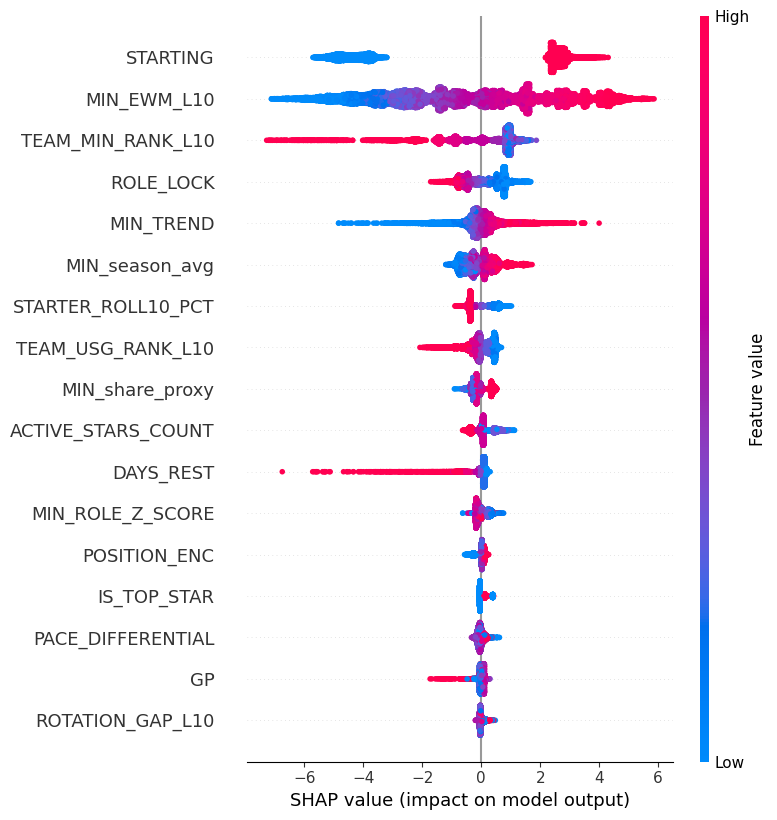

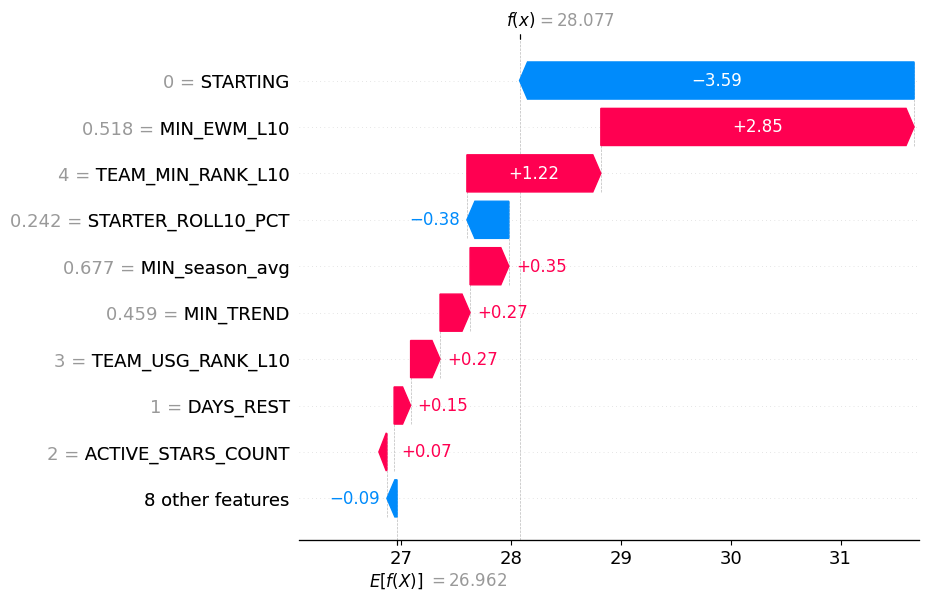

In [9]:
import shap

model = quantile_models["q_0.50"]   
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val)
shap.summary_plot(shap_values, X_val, feature_names=MIN_FEATURES)
shap.plots.waterfall(shap_values[1154])

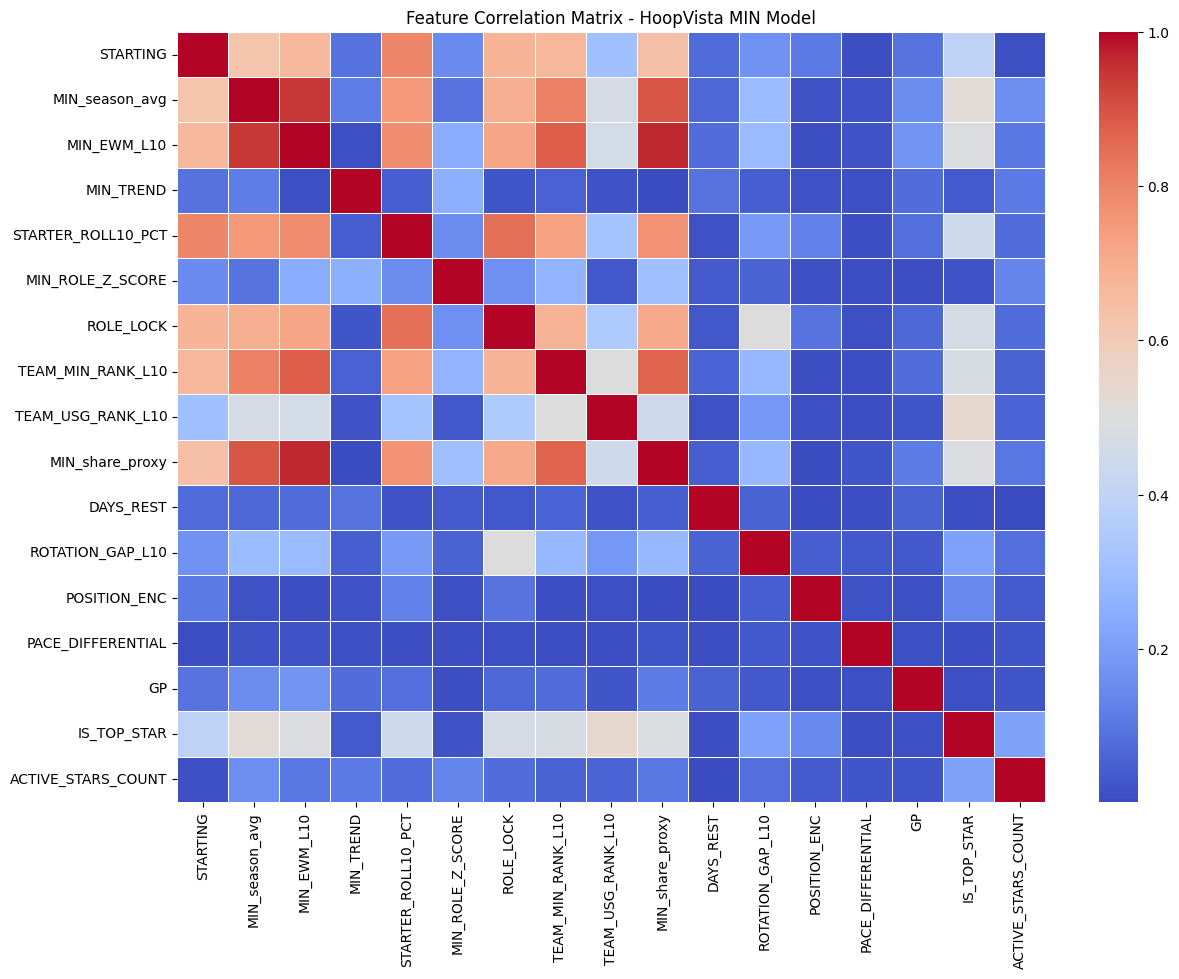

--- High Correlation Report (Threshold > 0.85) ---
MIN_share_proxy <-> MIN_EWM_L10: 0.9686
MIN_EWM_L10 <-> MIN_season_avg: 0.9422
MIN_share_proxy <-> MIN_season_avg: 0.8926
TEAM_MIN_RANK_L10 <-> MIN_EWM_L10: 0.8775
MIN_share_proxy <-> TEAM_MIN_RANK_L10: 0.8665


['MIN_EWM_L10', 'TEAM_MIN_RANK_L10', 'MIN_share_proxy']

In [10]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.85):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, MIN_FEATURES)
correlated_features

In [14]:
def check_quantile_calibration(y_true, y_pred, quantile):
    coverage = (y_true <= y_pred).mean()
    error = coverage - quantile
    print(f"Target Quantile: {quantile:.2f}")
    print(f"Actual Coverage: {coverage:.4f}")
    print(f"Calibration Error: {error:.4f}")
    return error

# y_val_min must align with X_val_min used to create quantile_preds
check_quantile_calibration(y_val, pred_low, 0.10)
check_quantile_calibration(y_val, pred_mid, 0.50)
check_quantile_calibration(y_val, pred_high, 0.90)

Target Quantile: 0.10
Actual Coverage: 0.1097
Calibration Error: 0.0097
Target Quantile: 0.50
Actual Coverage: 0.5258
Calibration Error: 0.0258
Target Quantile: 0.90
Actual Coverage: 0.9071
Calibration Error: 0.0071


np.float64(0.007135173897454217)

In [11]:
import joblib
from pathlib import Path

bundle = {
    "quantile_models": quantile_models,
    "feature_names": MIN_FEATURES,  # or list(X_train_min.columns)
    "scaler": scaler
}
joblib.dump(bundle, "src/models/saved_models/min_quantile_xgb.joblib")

['src/models/saved_models/min_quantile_xgb.joblib']

## Model Analysis

In [11]:
today = datetime.today().strftime('%Y%m%d')  
current_date = datetime.now().strftime('%Y-%m-%d')
target_date = pd.Timestamp("2026-03-26")
hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260408_145444.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
names = lines_dfs['NAME'].unique()
names

array(['James Harden', 'Donovan Mitchell', 'C.J. McCollum', 'Max Strus',
       'Nickeil Alexander-Walker', 'Cade Cunningham', 'Ausar Thompson',
       'A.J. Green', 'Franz Wagner', 'Julius Randle', 'Wendell Carter Jr',
       'Anthony Black', 'Tristan da Silva', 'Jrue Holiday',
       'Scoot Henderson', 'Dylan Harper', 'Kris Murray', 'Nikola Jokic',
       'Jamal Murray', 'Aaron Gordon', 'Bruce Brown', 'Cedric Coward',
       'Cooper Flagg', 'Khris Middleton', 'Dillon Brooks',
       'Dwight Powell', 'Kawhi Leonard', 'Shai Gilgeous-Alexander',
       'Jalen Williams', 'Chet Holmgren', 'Brook Lopez', 'Derrick Jones',
       'Isaiah Hartenstein', 'Ajay Mitchell', 'Jordan Miller'],
      dtype=object)

In [12]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        features = min_pipeline(hist, name, current_date)
        min_arr = np.asarray(features, dtype=float).reshape(1, -1)

        # Use MODELS (XGBRegressor), not quantile_preds (numpy arrays)
        q50 = float(quantile_models["q_0.50"].predict(min_arr)[0])
        q10 = float(quantile_models["q_0.10"].predict(min_arr)[0])
        q90 = float(quantile_models["q_0.90"].predict(min_arr)[0])

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": q10,
            "PRED_MIN_Q50": q50,
            "PRED_MIN_Q90": q90,
            "PRED_MIN_RANGE_10_90": q90 - q10,
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_MIN_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

[SKIP] A.J. Green: single positional indexer is out-of-bounds
[SKIP] Wendell Carter Jr: single positional indexer is out-of-bounds
[SKIP] Derrick Jones: single positional indexer is out-of-bounds


,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_MIN_RANGE_10_90
0,James Harden,14.782935,32.439739,39.285801,24.502866
1,Donovan Mitchell,11.219555,30.448065,38.572559,27.353004
2,CJ McCollum,16.344858,28.458870,37.034904,20.690046
3,Max Strus,13.768551,24.992159,29.632666,15.864115
4,Nickeil Alexander-Walker,17.052120,28.702499,37.912323,20.860203


In [23]:
import numpy as np

def run_player_simulation(row, n_sims=10000):
    sim_min = np.random.triangular(
        left=row["PRED_MIN_Q10"] * 0.85,
        mode=row["PRED_MIN_Q50"],
        right=row["PRED_MIN_Q90"] * 1.15,
        size=n_sims,
    )
    sim_min = np.clip(sim_min, 0, 48)
    return sim_min

all_sims = {}
for i, row in preds_df.iterrows():
    if not np.isnan(row["PRED_MIN_Q50"]):
        all_sims[row["PLAYER_NAME"]] = run_player_simulation(row)

In [24]:
import numpy as np
import pandas as pd

rows = []
for name, arr in all_sims.items():
    arr = np.asarray(arr, dtype=float)
    m = float(np.mean(arr))
    rows.append({
        "PLAYER_NAME": name,
        "sim_mean": round(m, 2),
        "sim_std": round(float(np.std(arr, ddof=0)), 2),
        "sim_p10": round(float(np.percentile(arr, 10)), 2),
        "sim_p90": round(float(np.percentile(arr, 90)), 2),
        "sim_interquartile_range": round(float(np.percentile(arr, 75) - np.percentile(arr, 25)), 2),
        "sim_span_p90_p10": round(float(np.percentile(arr, 90) - np.percentile(arr, 10)), 2),
        "coef_of_variation": round(float(np.std(arr) / m), 2) if m > 1 else np.nan,
    })

vol_df = pd.DataFrame(rows)
vol_df.sort_values("sim_interquartile_range", ascending=True, inplace=True)
vol_df.head(5)

,PLAYER_NAME,sim_mean,sim_std,sim_p10,sim_p90,sim_interquartile_range,sim_span_p90_p10,coef_of_variation
31,Jordan Miller,24.29,3.88,19.14,29.68,5.62,10.54,0.16
30,Ajay Mitchell,23.27,3.95,18.08,28.78,5.64,10.70,0.17
20,Cooper Flagg,34.63,4.11,28.97,40.08,5.92,11.11,0.12
14,Kris Murray,20.26,4.18,14.90,26.15,6.04,11.24,0.21
18,Bruce Brown,23.88,4.29,18.29,29.89,6.10,11.60,0.18
